<a href="https://colab.research.google.com/github/dytampn/TH_DeepLearning/blob/main/TH_DeepLearning_Tuan4_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
#data visualization packages
import matplotlib.pyplot as plt

In [2]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


In [3]:
num_classes = 10
input_shape = (28, 28, 1)
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


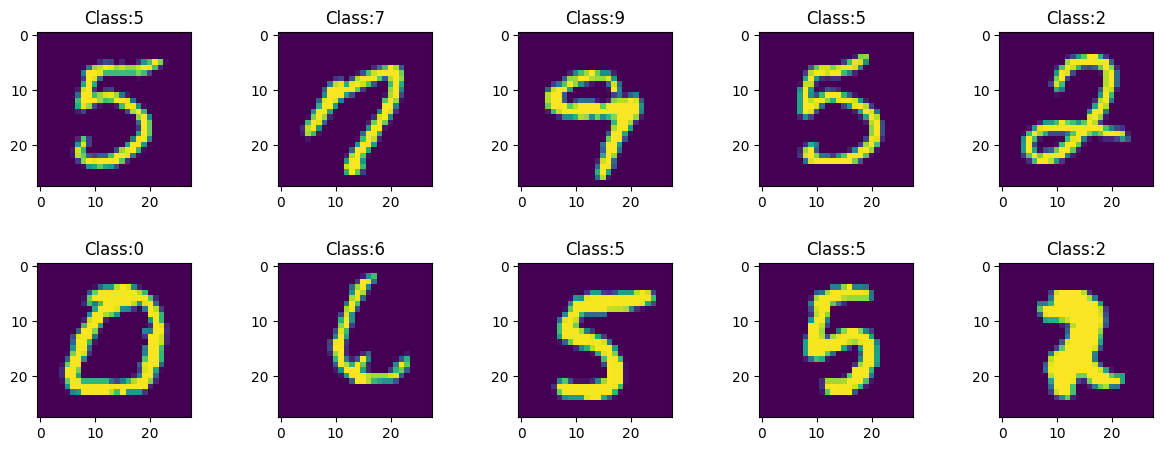

In [4]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class:' + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

In [5]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [7]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 109ms/step - accuracy: 0.8363 - loss: 0.5995 - val_accuracy: 0.9395 - val_loss: 0.2125
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 98ms/step - accuracy: 0.9554 - loss: 0.1473 - val_accuracy: 0.9575 - val_loss: 0.1458
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.9714 - loss: 0.0979 - val_accuracy: 0.9630 - val_loss: 0.1220
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.9774 - loss: 0.0761 - val_accuracy: 0.9730 - val_loss: 0.0926
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.9803 - loss: 0.0627 - val_accuracy: 0.9730 - val_loss: 0.0862
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - accuracy: 0.9834 - loss: 0.0525 - val_accuracy: 0.9710 - val_loss: 0.0957
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9843 - loss: 0.0460 - val_accuracy: 0.9715 - val_loss: 0.0913
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 17s 100ms/step - accuracy: 0.9866 - loss: 0.

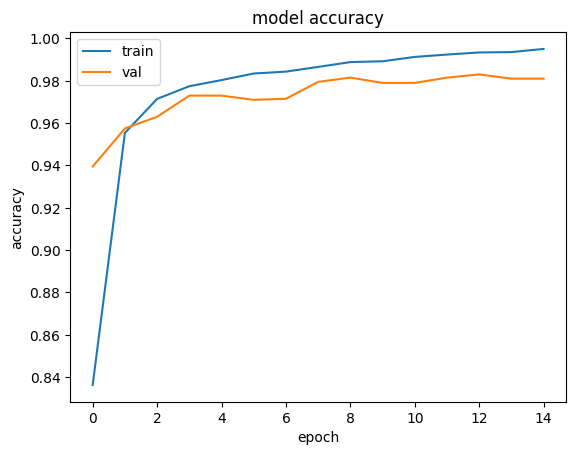

In [9]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

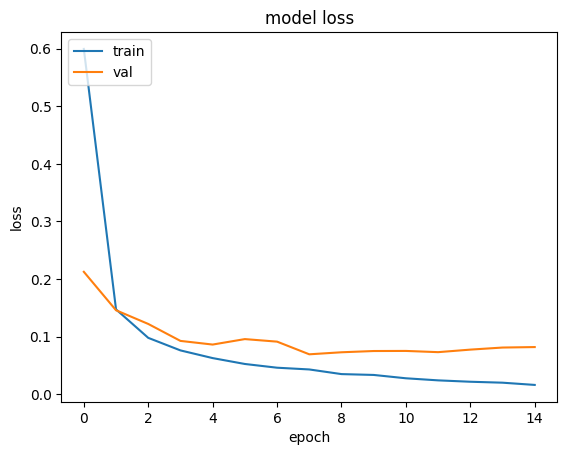

In [10]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [11]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 3s - 8ms/step - accuracy: 0.9828 - loss: 0.0643
Test loss: 0.06430520862340927
Test accuracy: 0.9827982783317566


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
[[3.4014270e-06 2.0594087e-05 9.9997592e-01 1.5156139e-10 8.4766380e-20
  4.3981383e-14 2.2917279e-08 2.9325016e-19 1.5896203e-09 3.9071783e-21]]
2 2


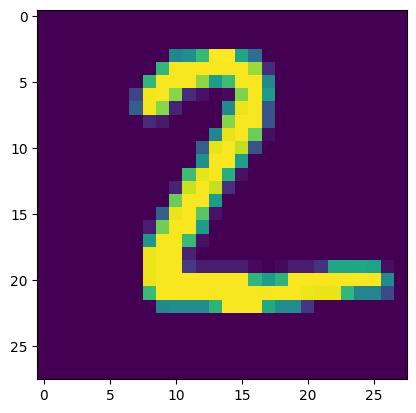

In [13]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
[[0.10687842 0.09725133 0.09961915 0.10008448 0.10060144 0.08566627
  0.09524135 0.1113326  0.10652353 0.09680147]]
7 1


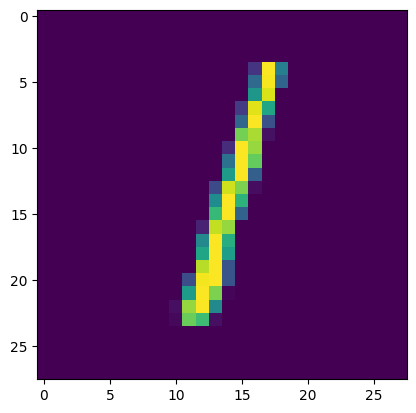

In [16]:
predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()